In [19]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [28]:
# Carichiamo il file Excel
file_path = "ARCA_SNIIP.xlsx"
excel_data = pd.read_excel(file_path, sheet_name=None,engine='openpyxl')

# Esploriamo i nomi dei fogli per capire dove cercare
sheet_names = list(excel_data.keys())

#arca21_df = excel_data['ARCA21']
#arca8_df = excel_data['ARCA8']

arca8_IIp = excel_data['ARCA8']
arca19_IIp = excel_data['ARCA19']
arca21_IIp = excel_data['ARCA21']


In [3]:
def save_data(filename, data1, data2, header1="Column 1", header2="Column 2"):
    """
    Salva due array di dati in un file di testo con due colonne.

    Parameters:
    filename (str): Nome del file di output.
    data1 (numpy array): Primo array di dati.
    data2 (numpy array): Secondo array di dati.
    header1 (str): Intestazione della prima colonna.
    header2 (str): Intestazione della seconda colonna.

    Output:
    Un file di testo con due colonne: data1 e data2.
    """
    data_to_save = np.column_stack((data1, data2))  # Combina i dati in due colonne
    header = f"{header1}   {header2}"  # Crea l'intestazione dinamicamente
    np.savetxt(filename, data_to_save, fmt="%.6e", header=header, comments='')






In [29]:

def build_sn_dict(df):
    sn_dict = {}
    for _, row in df.iterrows():
        sn_name = str(row['SN_NAME']).replace(" ", "").strip()
        try:
            distance = float(row['distance Mpc'])
            dec = float(row['DEC'])
            mrf = float(row['MRF'])
            mdp = float(row['MDP'])
            #mrf_arca8=float(row['ARCA8 MRF'])
            #mdp_arca8=float(row['ARCA8 MDP'])
            #mrf_arca21=float(row['ARCA21 MRF'])
            #mdp_arca21=float(row['ARCA21 MDP'])
        except (ValueError, TypeError):
            continue  # Salta righe con valori mancanti/non validi
        
        sn_dict[sn_name] = {
            'd_cm': distance * 3.086e24,
            'd_m': distance * 3.086e22,
            'MRF': mrf,
            'MDP': mdp,
            'dec': dec
            #'ARCA8 MRF':mrf_arca8,
            #'ARCA21 MRF':mrf_arca21,
            #'ARCA8 MDP':mdp_arca8,
            #'ARCA21 MDP':mdp_arca21
        }
    return sn_dict

# Creiamo i dizionari per entrambi i fogli
#sn_dict_arca21 = build_sn_dict(arca21_df)
#sn_dict_arca8 = build_sn_dict(arca8_df)
sn_dict_arca8IIp = build_sn_dict(arca8_IIp)
sn_dict_arca19IIp = build_sn_dict(arca19_IIp)
sn_dict_arca21IIp = build_sn_dict(arca21_IIp)
# Uniamo i dizionari, ARCA21 ha priorità in caso di duplicati
#sn_sources = {**sn_dict_arca8, **sn_dict_arca21}
sn_sources ={**sn_dict_arca8IIp, **sn_dict_arca19IIp, **sn_dict_arca21IIp}
# Mostriamo un'anteprima del dizionario finale
#dict(list(sn_sources.items())[:5])


SN IIn

In [25]:
# Dati MRF 
MRF_tot = np.array([5.59414,5.07397,4.41866,4.06071,3.75221,3.44035, 3.23166, 3.0832, 2.67603, 2.0977, 2.08528, 2.07631, 2.07851, 2.07851])
#d modello
d = 1 * 3.086e24 #1Mpc in cm
# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12  # eV
# Caricamento dati dal file
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)

if data.shape[1] > 7:
    # Estrazione dati dallo spettro
    Ev_all = data[:, 0]        # Energia in eV
    dN_dEv_all = data[:, 7]      # Spettro

    # Selezione dei dati a bassa energia (per il calcolo di flux_c)
    mask_valid = Ev_all 
    Ev_c = Ev_all[Ev_all>0.3e8] / 1e9   # in GeV
    dN_dEv_c = dN_dEv_all[Ev_all>0.3e8]

    # Selezione dei valori vicini a 1 TeV
    mask_fixed = np.isclose(Ev_all, E_fixed)
    Ev = Ev_all[Ev_all==E_fixed]
    dN_dEv = dN_dEv_all[Ev_all==E_fixed]

    # Calcolo dell'intervallo delta (se necessario)
    S_IIn_start = 1e5 * 10**(0.1 * (9 - 1))
    S_IIn_stop = 1e5 * 10**(0.1 * (26 - 1))
    delta = S_IIn_stop - S_IIn_start
    
    flux_c = Ev**2 * dN_dEv / (1e9 * 3 * 4 * np.pi * d**2)
        
    sensitivity_model = flux_c * MRF_tot
    # Funzioni per il calcolo del flux:
    # flux_calculation usa la distanza in cm, mentre flux_c usa la distanza in m
    def flux_calc(Ev_val, dN_dEv_val, d_cm):
        return (Ev_val**2 * dN_dEv_val) / (1e9 * 3 * 4 * np.pi * d_cm**2)
    
    def flux_c_calc(dN_dEv_vals, d_m):
        return (dN_dEv_vals * 1e9) / (6 * 4 * np.pi * d_m**2)
    
    # Calcolo flux e flux_c per ciascuna sorgente
    results = {}
    for sn, params in sn_sources.items():
        f = flux_calc(Ev, dN_dEv, params['d_cm'])
        f_c = flux_c_calc(dN_dEv_c, params['d_m'])
        results[sn] = {'flux': f, 'flux_c': f_c}
    
    # Generazione automatica del nome del file: "flux_c_<nome_supernova>.txt"
        filename = f"flux_c_{sn}.txt"
        '''save_data(filename, Ev_c, f_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")
        print(f"Dati salvati in {filename}")'''


SN IIP - ARCA8

In [30]:
d = 1 * 3.086e24 #1Mpc in cm
# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12  # eV

# Caricamento dati dal file
data = np.loadtxt("flux_IIp_tot.txt", skiprows=1)

# Estrazione dati dallo spettro
Ev_all = data[:, 0]        # Energia in eV
dN_dEv_all = data[:, 1]      # Spettro

# Selezione dei dati a bassa energia (per il calcolo di flux_c)
Ev_c = Ev_all  # in GeV
dN_dEv_c = dN_dEv_all

E_fixed = 1.07461e3
# Selezione dei valori vicini a 1 TeV
mask_fixed = np.isclose(Ev_all, E_fixed)
Ev = Ev_all[Ev_all==E_fixed]
dN_dEv = dN_dEv_all[Ev_all==E_fixed]

flux_c = Ev**2 * dN_dEv / (3 * 4 * np.pi * d**2)
    
#sensitivity_model = flux_c * MRF_tot
# Funzioni per il calcolo del flux:
# flux_calculation usa la distanza in cm, mentre flux_c usa la distanza in m
def flux_calc(Ev_val, dN_dEv_val, d_cm):
    return (Ev_val**2 * 2 * dN_dEv_val * 3.086e22**2) / ( d_cm**2)

def flux_c_calc(dN_dEv_vals, d_m):
    return (dN_dEv_vals*3.086e22**2) / (d_m**2)

# Calcolo flux e flux_c per ciascuna sorgente
results = {}
for sn, params in sn_dict_arca8IIp.items():
    f = flux_calc(Ev, dN_dEv, params['d_cm'])
    f_c = flux_c_calc(dN_dEv_c, params['d_m'])
    results[sn] = {'flux': f, 'flux_c': f_c}

# Generazione automatica del nome del file: "flux_c_<nome_supernova>.txt"
    '''filename = f"flux_c_{sn}.txt"
    save_data(filename, Ev_c, f_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")
    print(f"Dati salvati in {filename}")'''

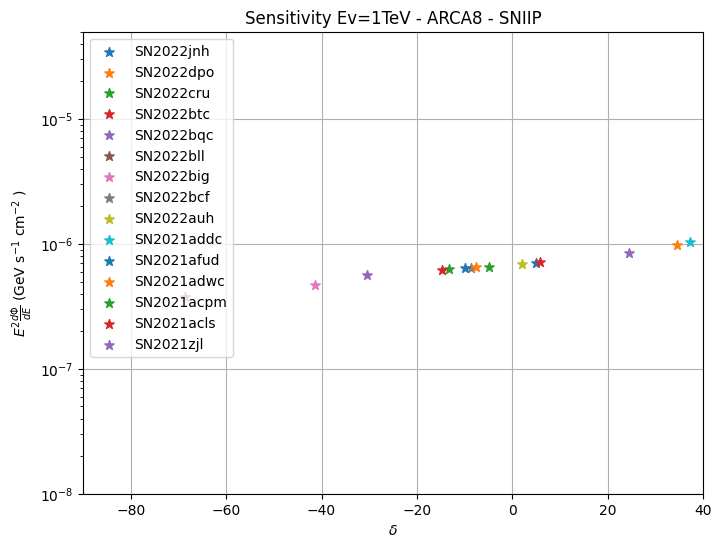

In [32]:
# Preparazione del plot
plt.figure(figsize=(8, 6))
plt.yscale("log")

# Plot delle sorgenti con scatter
for sn, params in sn_dict_arca8IIp.items():
    # Si utilizza il flux calcolato e il moltiplicatore specificato per ottenere il valore da plottare
    y_val = np.array(results[sn]['flux'] * params['MRF'])
    x_val = np.array(params['dec'])
    plt.scatter(x_val, y_val, marker='*', s=50, zorder=3, label=sn)
    #plt.text(x_val, y_val * 1.1, sn, fontsize=8, color='blue', ha='right')

# Plot della sensibilità per SN2023esp (linea rossa)
#plt.plot(delta_list, sensitivity_weighted, color='red', label="Sensitivity Ev=1TeV")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.ylim(1e-8,5e-5)
plt.xlim(-90,40)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV - ARCA8 - SNIIP')
plt.legend()
plt.show()


IIP - ARCA21

In [33]:
d = 1 * 3.086e24 #1Mpc in cm
# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12  # eV

# Caricamento dati dal file
data = np.loadtxt("flux_IIp_tot.txt", skiprows=1)

# Estrazione dati dallo spettro
Ev_all = data[:, 0]        # Energia in eV
dN_dEv_all = data[:, 1]      # Spettro

# Selezione dei dati a bassa energia (per il calcolo di flux_c)
Ev_c = Ev_all  # in GeV
dN_dEv_c = dN_dEv_all

E_fixed = 1.07461e3
# Selezione dei valori vicini a 1 TeV
mask_fixed = np.isclose(Ev_all, E_fixed)
Ev = Ev_all[Ev_all==E_fixed]
dN_dEv = dN_dEv_all[Ev_all==E_fixed]

flux_c = Ev**2 * dN_dEv / (3 * 4 * np.pi * d**2)
    
#sensitivity_model = flux_c * MRF_tot
# Funzioni per il calcolo del flux:
# flux_calculation usa la distanza in cm, mentre flux_c usa la distanza in m
def flux_calc(Ev_val, dN_dEv_val, d_cm):
    return (Ev_val**2 * 2 * dN_dEv_val * 3.086e22**2) / ( d_cm**2)

def flux_c_calc(dN_dEv_vals, d_m):
    return (dN_dEv_vals*3.086e22**2) / (d_m**2)

# Calcolo flux e flux_c per ciascuna sorgente
results = {}
for sn, params in sn_dict_arca21IIp.items():
    f = flux_calc(Ev, dN_dEv, params['d_cm'])
    f_c = flux_c_calc(dN_dEv_c, params['d_m'])
    results[sn] = {'flux': f, 'flux_c': f_c}

# Generazione automatica del nome del file: "flux_c_<nome_supernova>.txt"
    '''filename = f"flux_c_{sn}.txt"
    save_data(filename, Ev_c, f_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")
    print(f"Dati salvati in {filename}")'''

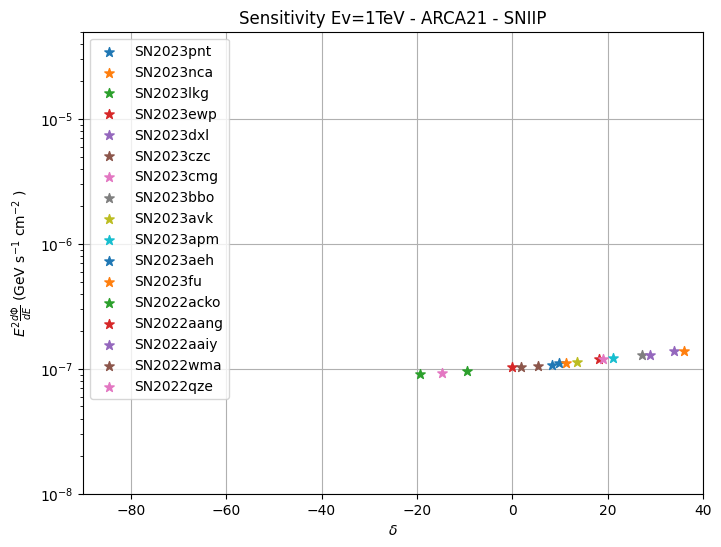

In [34]:
# Preparazione del plot
plt.figure(figsize=(8, 6))
plt.yscale("log")

# Plot delle sorgenti con scatter
for sn, params in sn_dict_arca21IIp.items():
    # Si utilizza il flux calcolato e il moltiplicatore specificato per ottenere il valore da plottare
    y_val = np.array(results[sn]['flux'] * params['MRF'])
    x_val = np.array(params['dec'])
    plt.scatter(x_val, y_val, marker='*', s=50, zorder=3, label=sn)
    #plt.text(x_val, y_val * 1.1, sn, fontsize=8, color='blue', ha='right')

# Plot della sensibilità per SN2023esp (linea rossa)
#plt.plot(delta_list, sensitivity_weighted, color='red', label="Sensitivity Ev=1TeV")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.ylim(1e-8,5e-5)
plt.xlim(-90,40)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV - ARCA21 - SNIIP')
plt.legend()
plt.show()


IIP ARCA19

In [35]:
d = 1 * 3.086e24 #1Mpc in cm
# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12  # eV

# Caricamento dati dal file
data = np.loadtxt("flux_IIp_tot.txt", skiprows=1)

# Estrazione dati dallo spettro
Ev_all = data[:, 0]        # Energia in eV
dN_dEv_all = data[:, 1]      # Spettro

# Selezione dei dati a bassa energia (per il calcolo di flux_c)
Ev_c = Ev_all  # in GeV
dN_dEv_c = dN_dEv_all

E_fixed = 1.07461e3
# Selezione dei valori vicini a 1 TeV
mask_fixed = np.isclose(Ev_all, E_fixed)
Ev = Ev_all[Ev_all==E_fixed]
dN_dEv = dN_dEv_all[Ev_all==E_fixed]

flux_c = Ev**2 * dN_dEv / (3 * 4 * np.pi * d**2)
    
#sensitivity_model = flux_c * MRF_tot
# Funzioni per il calcolo del flux:
# flux_calculation usa la distanza in cm, mentre flux_c usa la distanza in m
def flux_calc(Ev_val, dN_dEv_val, d_cm):
    return (Ev_val**2 * 2 * dN_dEv_val * 3.086e22**2) / ( d_cm**2)

def flux_c_calc(dN_dEv_vals, d_m):
    return (dN_dEv_vals*3.086e22**2) / (d_m**2)

# Calcolo flux e flux_c per ciascuna sorgente
results = {}
for sn, params in sn_dict_arca19IIp.items():
    f = flux_calc(Ev, dN_dEv, params['d_cm'])
    f_c = flux_c_calc(dN_dEv_c, params['d_m'])
    results[sn] = {'flux': f, 'flux_c': f_c}

# Generazione automatica del nome del file: "flux_c_<nome_supernova>.txt"
    '''filename = f"flux_c_{sn}.txt"
    save_data(filename, Ev_c, f_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")
    print(f"Dati salvati in {filename}")'''

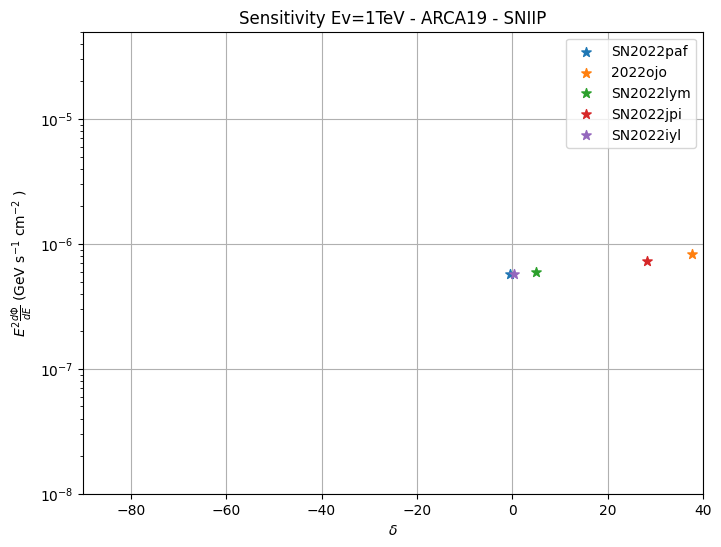

In [36]:
# Preparazione del plot
plt.figure(figsize=(8, 6))
plt.yscale("log")

# Plot delle sorgenti con scatter
for sn, params in sn_dict_arca19IIp.items():
    # Si utilizza il flux calcolato e il moltiplicatore specificato per ottenere il valore da plottare
    y_val = np.array(results[sn]['flux'] * params['MRF'])
    x_val = np.array(params['dec'])
    plt.scatter(x_val, y_val, marker='*', s=50, zorder=3, label=sn)
    #plt.text(x_val, y_val * 1.1, sn, fontsize=8, color='blue', ha='right')

# Plot della sensibilità per SN2023esp (linea rossa)
#plt.plot(delta_list, sensitivity_weighted, color='red', label="Sensitivity Ev=1TeV")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.ylim(1e-8,5e-5)
plt.xlim(-90,40)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV - ARCA19 - SNIIP')
plt.legend()
plt.show()


II n

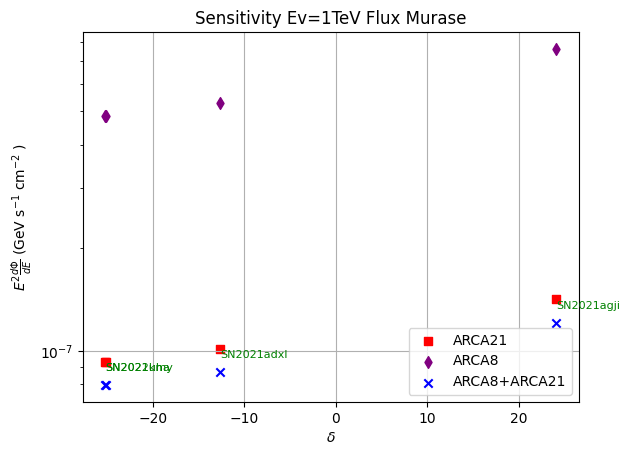

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Primo disegno dei punti per la legenda (punti "fittizi", fuori dal ciclo)
plt.scatter([], [], marker='s', color='red', label='ARCA21')
plt.scatter([], [], marker='d', color='purple', label='ARCA8')
plt.scatter([], [], marker='x', color='blue', label='ARCA8+ARCA21')

# Plot delle sorgenti con scatter (solo se MRF ≠ 0 e non NaN)
for sn, params in sn_sources.items():
    mrf = params['MRF']
    mrf_8 = params['ARCA8 MRF']
    mrf_21 = params['ARCA21 MRF']
    
    # Salta se MRF è zero o NaN
    if mrf == 0 or np.isnan(mrf):
        continue

    # Calcolo dei valori da plottare
    y_val = np.array(results[sn]['flux'] * mrf)
    y_val_arca8 = np.array(results[sn]['flux'] * mrf_8)
    y_val_arca21 = np.array(results[sn]['flux'] * mrf_21)
    x_val = np.array(params['dec'])

    # Scatter plot senza label per non duplicare in legenda
    plt.scatter(x_val, y_val_arca21, marker='s', color='red', zorder=1)
    plt.scatter(x_val, y_val_arca8, marker='d', color='purple', zorder=1)
    plt.scatter(x_val, y_val, marker='x', color='blue', zorder=1)
    plt.text(x_val, y_val * 1.1, sn, fontsize=8, color='green')

# Etichette e formattazione
plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.grid(True)
plt.yscale('log')
plt.title('Sensitivity Ev=1TeV Flux Murase')

plt.legend()
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_23336\2019407387.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('prism', num_sns)


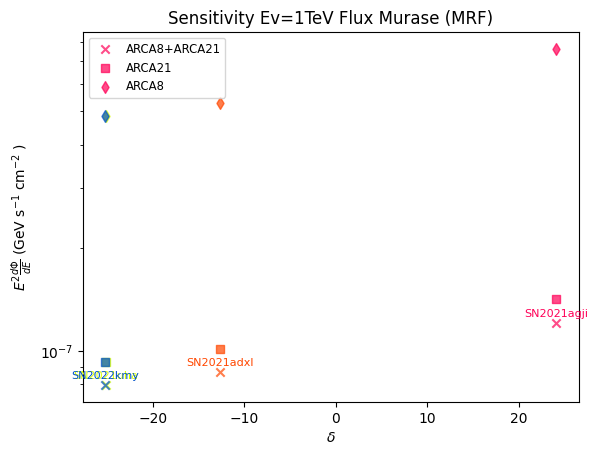

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Genera una mappa di colori unici per ogni SN
sns = list(sn_sources.keys())
num_sns = len(sns)
color_map = cm.get_cmap('prism', num_sns)

# Per evitare label duplicate nella legenda
label_flags = {
    'ARCA8': False,
    'ARCA21': False,
    'ARCA8+ARCA21': False
}

# Plot delle sorgenti con scatter (solo se MRF ≠ 0 e non NaN)
for i, sn in enumerate(sns):
    params = sn_sources[sn]
    mrf = params['MRF']
    mrf_8 = params['ARCA8 MRF']
    mrf_21 = params['ARCA21 MRF']

    if mrf == 0 or np.isnan(mrf):
        continue

    y_val = np.array(results[sn]['flux'] * mrf)
    y_val_arca8 = np.array(results[sn]['flux'] * mrf_8)
    y_val_arca21 = np.array(results[sn]['flux'] * mrf_21)
    x_val = np.array(params['dec'])

    color = color_map(i)

    # Etichette solo la prima volta
    label_arca = 'ARCA8' if not label_flags['ARCA8'] else None
    label_arca21 = 'ARCA21' if not label_flags['ARCA21'] else None
    label_combo = 'ARCA8+ARCA21' if not label_flags['ARCA8+ARCA21'] else None

    plt.scatter(x_val, y_val, marker='x', color=color, alpha=0.7, label=label_combo)
    plt.scatter(x_val, y_val_arca21, marker='s', color=color, alpha=0.7, zorder=1, label=label_arca21)
    plt.scatter(x_val, y_val_arca8, marker='d', color=color, alpha=0.7, zorder=1, label=label_arca)

    plt.text(x_val, y_val * 1.1, sn, fontsize=8, color=color, ha='center', va='top')

    # Aggiorna i flag per la legenda
    label_flags['ARCA8'] = True
    label_flags['ARCA21'] = True
    label_flags['ARCA8+ARCA21'] = True

# Etichette e formattazione
plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")

plt.yscale('log')
plt.title('Sensitivity Ev=1TeV Flux Murase (MRF)')
plt.legend(loc='best', fontsize='small')
plt.show()


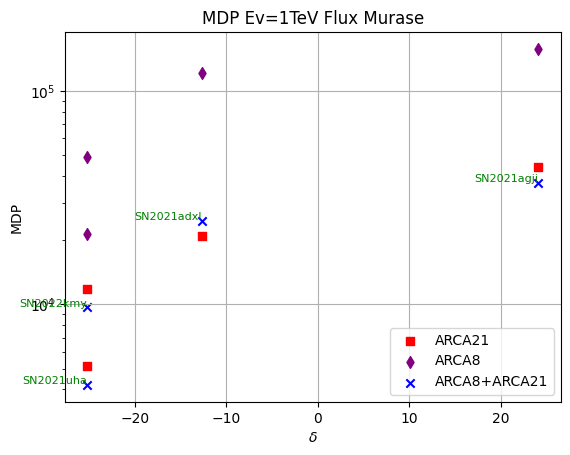

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter "fittizi" per la legenda
plt.scatter([], [], marker='s', color='red', label='ARCA21')
plt.scatter([], [], marker='d', color='purple', label='ARCA8')
plt.scatter([], [], marker='x', color='blue', label='ARCA8+ARCA21')

# Plot delle sorgenti con MDP ≠ 0
for sn, params in sn_sources.items():
    mdp = params.get('MDP', float('nan'))  # safe fallback
    mdp_8 = params['ARCA8 MDP']
    mdp_21 = params['ARCA21 MDP']
    if mdp == 0 or np.isnan(mdp):
        continue
    
    y_val = np.array( mdp)
    y_val_arca8 = np.array( mdp_8)
    y_val_arca21 = np.array( mdp_21)
    x_val = np.array(params['dec'])

    plt.scatter(x_val, y_val, marker='x', color='blue', zorder=1)
    plt.scatter(x_val, y_val_arca21, marker='s', color='red', zorder=1)
    plt.scatter(x_val, y_val_arca8, marker='d', color='purple', zorder=1)
    plt.text(x_val, y_val * 1.1, sn, fontsize=8, color='green', ha='right', va='top')

plt.xlabel(r"$\delta$")
plt.ylabel("MDP")
plt.grid(True)
plt.title('MDP Ev=1TeV Flux Murase')
plt.yscale('log')  # Se ti serve scala log, altrimenti commenta
plt.legend()
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_23336\954605556.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('prism', num_sns)


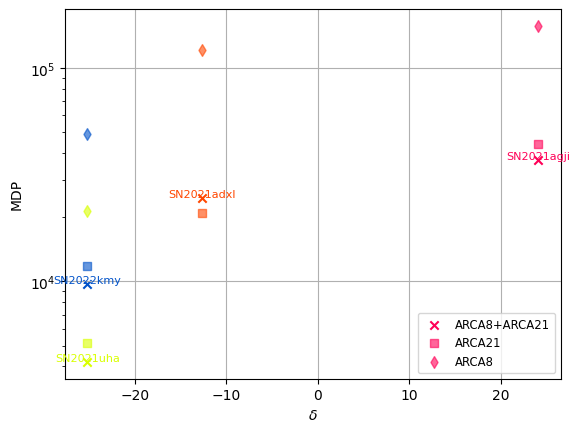

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Genera una mappa di colori unici per ogni SN
sns = list(sn_sources.keys())
num_sns = len(sns)
color_map = cm.get_cmap('prism', num_sns)

# Per evitare label duplicate nella legenda
label_flags = {
    'ARCA8': False,
    'ARCA21': False,
    'ARCA8+ARCA21': False
}

# Plot delle sorgenti con MDP ≠ 0
for i, sn in enumerate(sns):
    params = sn_sources[sn]
    mdp = params.get('MDP', float('nan'))
    mdp_8 = params['ARCA8 MDP']
    mdp_21 = params['ARCA21 MDP']

    if mdp == 0 or np.isnan(mdp):
        continue

    y_val = np.array( mdp)
    y_val_arca8 = np.array(mdp_8)
    y_val_arca21 = np.array(mdp_21)
    x_val = np.array(params['dec'])

    color = color_map(i)

    # Una sola etichetta per tipo di combinazione
    label_arca = 'ARCA8' if not label_flags['ARCA8'] else None
    label_arca21 = 'ARCA21' if not label_flags['ARCA21'] else None
    label_combo = 'ARCA8+ARCA21' if not label_flags['ARCA8+ARCA21'] else None

    plt.scatter(x_val, y_val, marker='x', color=color, zorder=1, label=label_combo)
    plt.scatter(x_val, y_val_arca21, marker='s', color=color, alpha=0.6, zorder=1, label=label_arca21)
    plt.scatter(x_val, y_val_arca8, marker='d', color=color, alpha=0.6, zorder=1, label=label_arca)

    plt.text(x_val, y_val * 1.1, sn, fontsize=8, color=color, ha='center', va='top')

    # Imposta i flag per evitare duplicati
    label_flags['ARCA8'] = True
    label_flags['ARCA21'] = True
    label_flags['ARCA8+ARCA21'] = True

# Etichette e formattazione
plt.xlabel(r"$\delta$")
plt.ylabel(r"MDP")
plt.grid(True)
plt.yscale('log')

plt.legend(loc='best', fontsize='small')
plt.show()
